## Model based Trading Strategy Development.
The process includes: 

1. Constructing a database 
2. Exploratory Data Analysis 
3. Trading Hypothesis Development and Implementation 
5. Analyze Strategy performance.

**We walk through these steps to illustrate the entire workflow.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas_ta as ta
from pandas_datareader.data import DataReader
from datetime import date, datetime, timedelta
import statsmodels.api as sm

### **Database Construction**
- Pandas DataReader

- Other Data sources: 

    - The Federal Reserve has an online portal called FRED.. For example, monetary policy, fiscal policy, and commodity prices.

    - source = 'fred'.  Each series has a code: https://fred.stlouisfed.org/
    
- https://pandas-datareader.readthedocs.io/en/latest/remote_data.html




In [2]:
# TO DO: Import Oil price Data from FRED spannng the given dates
end_date = date(2019,12,31)
begin_date = date(2004,1,1)
df = DataReader('DCOILWTICO', 'fred',  begin_date, end_date)

df.to_csv('data/oil.csv') 

df = pd.read_csv('data/oil.csv', parse_dates=['DATE'], index_col='DATE')

df.columns = ['price']
daily_close = df['price']
df

,price
DATE,
2004-01-01,NaN
2004-01-02,NaN
2004-01-05,33.71
2004-01-06,33.54
2004-01-07,33.57
...,...
2019-12-25,NaN
2019-12-26,61.72
2019-12-27,61.76


### Exploratory Data Analysis ##
To understand the data, we can first take a quick look by, for example:
- Summary statistics
- Data Visualization: 
    - histograms, for example, present an quick check whether underlying data distribution could be normal.  
- Returns vs. Lookahead Returns

In [3]:
df.describe()

,price
count,4019.000000
mean,70.223284
std,22.502479
min,26.190000
25%,51.890000
50%,65.910000
75%,89.790000
max,145.310000


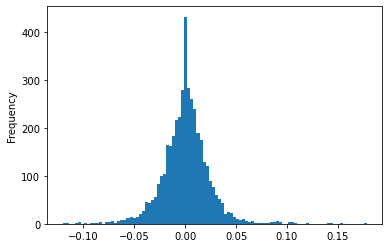

In [4]:
df['price'].pct_change().plot(kind='hist', bins=100)
None

### **Exercise: Compute monthly returns using the Oil data.**
* First obtain month-end prices.
    * Resample daily prices at a monthly frequency to obtain monthly prices
    * monthly_prices = prices.resample('M').last()
    
* Monthly returns can then be computed from monthly prices:
    * Returns measure changes in prices.
    * For each period t in the sample, a return R<sub>t</sub> can be computed.
    * R<sub>t</sub>  = (P<sub>t</sub> - P<sub>t-1</sub>)/P<sub>t-1</sub>.    
    
* pct_change() suffices here.
    
The current return is a simple variable with possible predictive power. 

In [5]:
### TO DO: create monthly returns
df = df.resample('M').last()
df['returns'] = df['price'].pct_change()
df

,price,returns
DATE,,
2004-01-31,33.16,NaN
2004-02-29,36.08,0.088058
2004-03-31,35.75,-0.009146
2004-04-30,37.31,0.043636
2004-05-31,39.90,0.069418
...,...,...
2019-08-31,55.07,-0.059115
2019-09-30,54.09,-0.017796
2019-10-31,54.02,-0.001294


### **Exercise: Create "look-ahead" future returns.**
- These are how prices changed in our data from the current period to the next period
- Our predictive models will target these future price changes
- df.shift()

In [6]:
### TO DO: create lookahead return series
df['lookahead_returns'] = df['returns'].shift(-1) 
df.head()

,price,returns,lookahead_returns
DATE,,,
2004-01-31,33.16,NaN,0.088058
2004-02-29,36.08,0.088058,-0.009146
2004-03-31,35.75,-0.009146,0.043636
2004-04-30,37.31,0.043636,0.069418
2004-05-31,39.90,0.069418,-0.074687


In [7]:
pd.concat([df['returns'],df['lookahead_returns']],axis='columns').corr()

,returns,lookahead_returns
returns,1.000000,0.185157
lookahead_returns,0.185157,1.000000


### **To make predictions we estimate models using data**

-  We use data that we believe capture the state of the economy
- The recent academic Finance literature posits several insrumental variable as predictors of future prices.

    - See Professor Goyal's website

    http://www.hec.unil.ch/agoyal/
 
 
- For instruments in common practice (e.g. rsi) we can use the the pandas-ta library

<br>

### **Trading Strategy Development**
* Suppose we have a model that generates predictions about future price movements.
* A natural Trading Strategy formulation :

| Signal | Condition |
|----|------|
| 1 | Predicted Return > 0 |
| -1  | Predicted Return < 0 |
| 0  | Otherwise |

* In this chart, **Predicted Return** is the variable generated from estimating the model estimation.  
* So, when the model predicts a positive return (i.e. an increase in prices) we buy 1 unit and vice versa.

**Can you think of another rule?**

In [8]:
instrument_names = ['returns'] 
df_instruments = pd.read_csv('data/PredictorData2019.csv', parse_dates=['DATE'], index_col='DATE')

df = df.join(df_instruments)

imported_instruments = df_instruments.columns
instrument_names.extend(imported_instruments)

In [9]:
for l in [10, 20, 40, 60]:  

    # Compute moving average using the pandas-ta library
    df['ma' + str(l)] = ta.sma(daily_close, length = l)
    # Compute Relative Strength Indicators
    df['rsi' + str(l)] = ta.rsi(daily_close, l)
    
    # Update list of instrument names
    instrument_names = instrument_names + ['ma' + str(l), 'rsi' + str(l)]
    
instrument_names

['returns',
 'Index',
 'D12',
 'E12',
 'b/m',
 'tbl',
 'AAA',
 'BAA',
 'lty',
 'ntis',
 'Rfree',
 'infl',
 'ltr',
 'corpr',
 'svar',
 'csp',
 'CRSP_SPvw',
 'CRSP_SPvwx',
 'ma10',
 'rsi10',
 'ma20',
 'rsi20',
 'ma40',
 'rsi40',
 'ma60',
 'rsi60']

### Create separate instrument and lookahead returns variables
* We now have instruments that we will use to try to predict our target (lookahead returns).

### Issue 1: Missing data
* Drop it.
* Replace with zero


**Can you think of an alternative?**

In [10]:
# For simiplicity, here we can set any missing values to zero
df.fillna(0,inplace=True) 

## Impute the null value with the median value
#df.fillna(df.median(),inplace=True)


# Create instruments and target variables
instruments = df[instrument_names] 
print(instruments.head())

             returns    Index        D12        E12       b/m     tbl     AAA  \
DATE                                                                            
2004-01-31  0.000000  1131.13  17.598000  49.826667  0.218028  0.0088  0.0554   
2004-02-29  0.088058  1144.94  17.811000  50.913333  0.216053  0.0093  0.0550   
2004-03-31 -0.009146  1126.21  18.024000  52.000000  0.281731  0.0094  0.0533   
2004-04-30  0.043636  1107.30  18.216667  53.383333  0.285372  0.0094  0.0573   
2004-05-31  0.069418  1120.68  18.409333  54.766667  0.286412  0.0102  0.0604   

               BAA     lty      ntis  ...  CRSP_SPvw  CRSP_SPvwx    ma10  \
DATE                                  ...                                  
2004-01-31  0.0644  0.0499  0.006846  ...   0.019078    0.017991   0.000   
2004-02-29  0.0627  0.0483  0.009327  ...   0.014403    0.012716   0.000   
2004-03-31  0.0611  0.0474  0.012246  ...  -0.014982   -0.016267  36.648   
2004-04-30  0.0646  0.0531  0.013730  ...  -0.015584

In [11]:
lookahead_returns = df['lookahead_returns']
print(lookahead_returns.head())

DATE
2004-01-31    0.088058
2004-02-29   -0.009146
2004-03-31    0.043636
2004-04-30    0.069418
2004-05-31   -0.074687
Freq: M, Name: lookahead_returns, dtype: float64


###  **Issue 2: Specify the model, fit it and make predictions**

* Set aside 10-20% of the recent data for out of sample analysis

* Why:
    * ensure that we are not overfitting our model to the data 
    * evaluate our model's performance on data it has not "seen".

###  **How closely can models fit in-sample data?**




In [12]:
# Reserve 10% of the data for out-of-sample analysis
is_size = int(0.9 * instruments.shape[0])


# Add a constant to the instruments
instruments = sm.add_constant(instruments)
instrument_names.extend(['const'])

is_instruments = instruments[:is_size]
is_lookahead_returns = lookahead_returns[:is_size]

print(instruments.shape, is_instruments.shape)

(192, 27) (172, 27)


###  **Issue 3: Specify the model, fit it and make predictions (II)**

- model = sm.OLS(is_lookahead_returns, is_instruments)
- results = model.fit()
- is_predictions = results.predict(is_instruments)


### **Which model?**
### **How different is it to fit nonlinear models?**

In [13]:
model = sm.OLS(is_lookahead_returns, is_instruments)
results = model.fit() 

### Exercise: Use the model estimaton to make predictions
  
* After fitting the model, we can make predictions using the .predict() function of our results object.
    

In [14]:
#TO DO:  Use the model estimaton to make predictions
is_predictions = results.predict(is_instruments)

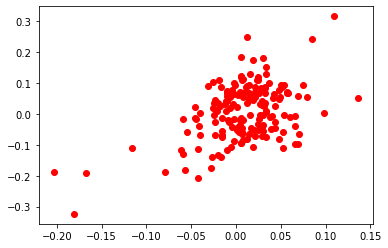

In [15]:
# TO DO: Scatter the predicted versus realized returns
plt.scatter(is_predictions, is_lookahead_returns, color='r')
None

### Strategy Formulation

Now we can start incorporating our model prediction into a strategy.  A natural first step is to create long and short signals as follows:

| Signal | Condition |
|----|------|
| 1 | Predicted Return > 0 |
| -1  | Predicted Return < 0 |
| 0  | Otherwise |

* In this chart, **Predicted Return** is the variable generated from estimating the model estimation.  
* So, when the model predicts a positive return (i.e. an increase in prices) we buy 1 unit and vice versa.

### **Exercise: implement the above Strategy Formulation to generate trading postions.**
* For example, in computing shortPositions
    * Compare predictions to 0: is_predictions < 0
    * Convert the comparison to an integer: ().astype(int)
    * Multiply result by -1, because you want to short in this case.

In [16]:
# TO DO: implement the above logic to create a short and long positions variable.  
 
shortPositions = (is_predictions < 0).astype(int)  * -1
longPositions  = (is_predictions  > 0).astype(int) * 1

positions = shortPositions + longPositions

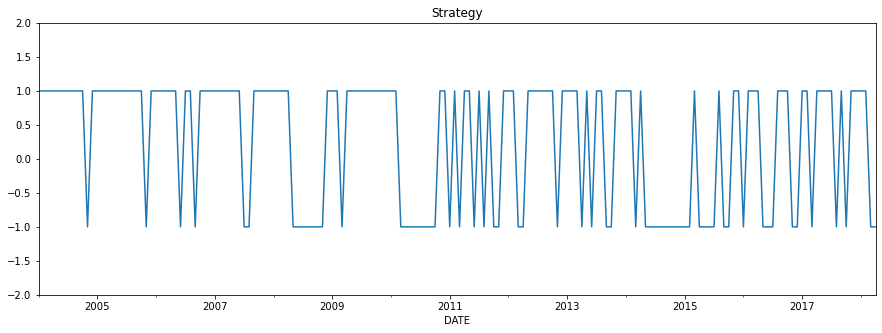

In [17]:
positions.plot(title="Strategy",ylim=(-2,2),figsize=(15,5))
None

### **Exercise: Compute the returns that the strategy earns**
*  At each date, we take a position, long one unit or short one unit.
* In either case, the strategy earns position*is_lookahead_return


In [18]:
#TO DO: Compute strategy returns
stratReturns = (positions*is_lookahead_returns)

### **Exercise: Compute the mean and variance of the returns that the strategy earns**
*  Recall that the strategy earns a return each period, so we can compute the mean of this time series.
* stratReturnsMean = stratReturns.mean()

In [19]:
stratReturnsMean = stratReturns.mean()
stratReturnsVar = stratReturns.var()

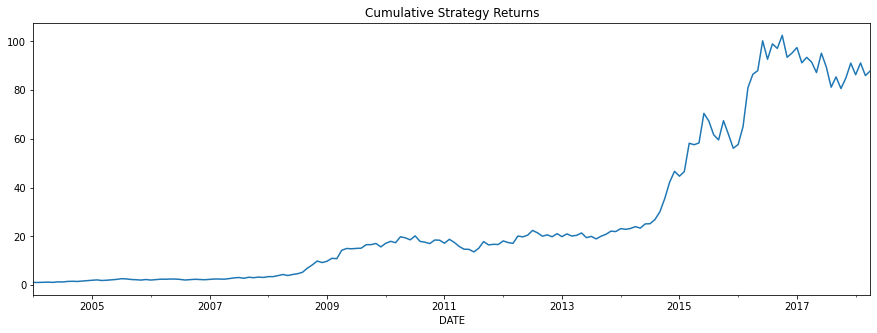

In [20]:
(1+stratReturns).cumprod().plot(figsize=(15,5), title="Cumulative Strategy Returns")
None

### **Exercise: Annualize the mean and variance**
*  The holding period for the strategy is one month
*  The mean return we have computed is for one month, similarly we have computed the variance of monthly returns.
* To annualize mean and variance, we multiply each by 12.

In [21]:
annConst = 12
#TO DO: 
stratReturnsMeanAnnualRate = stratReturnsMean * annConst
stratReturnsVarAnnualRate = stratReturnsVar * annConst

### **Exercise: Compute the risk adjusted mean return**
* Consider the mean return earned per unit of risk
    * The traditional measure of risk here is the standard deviation of strategy returns.
    * Note that the mean return used in this computatin is in excess of the risk-free rate, but for simplicity we can assume here that the risk-free rate is zero.
* This measure is termed the Sharpe Ratio.

In [22]:
Rf = 0
# TO DO: Compute the Risk Adjusted mean return for this strategy
stratReturnsSdAnnualRate = np.sqrt(stratReturnsVarAnnualRate)
sh = (stratReturnsMeanAnnualRate - Rf) /stratReturnsSdAnnualRate

In [23]:
sh

1.2012072765844668